In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| include: false
packages = ["SymPyPythonCall", "Plots", "DifferentialEquations", "LaTeXStrings", "NLSolve"]

5-element Vector{String}:
 "SymPyPythonCall"
 "Plots"
 "DifferentialEquations"
 "LaTeXStrings"
 "NLSolve"

In [3]:
#| echo: false
#| include: false
using Plots
# Plots y Makie generan además una representación text/html con la imagen en base64
# en una sola línea; con figuras grandes esa línea desborda la pila del conversor
# de Quarto a Markdown. La desactivamos y dejamos solo image/png.
Base.showable(::MIME"text/html", ::Plots.Plot) = false

In [4]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("![](https://img.shields.io/badge/Julia-$(v)-9558B2?logo=julia)")

![](https://img.shields.io/badge/Julia-1.12.6-9558B2?logo=julia)


In [5]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("**Versión de Julia:** $(v)")

**Versión de Julia:** 1.12.6


In [6]:
#| echo: false
#| include: false
import Pkg
active_project = Base.active_project()
global_env = joinpath(homedir(), ".julia", "environments", "v$(VERSION.major).$(VERSION.minor)", "Project.toml")
Pkg.activate(global_env)

  Activating project at `~/.julia/environments/v1.12`


In [7]:
#| echo: false
Pkg.status(packages)

Status `~/.julia/environments/v1.12/Project.toml`
  [0c46a032] DifferentialEquations v8.0.2
  [b964fa9f] LaTeXStrings v1.4.0
  [91a5bcdd] Plots v1.41.6
  [bc8888f7] SymPyPythonCall v0.5.1


In [8]:
#| echo: false
#| include: false
#Pkg.activate(active_project)

In [9]:
function campo_vectorial(f, g, xs, ys; escala = 0.35, kwargs...)
    X = [x for y in ys for x in xs]
    Y = [y for y in ys for x in xs]
    U = f.(X, Y)
    V = g.(X, Y)
    N = sqrt.(U .^ 2 .+ V .^ 2) .+ 1e-12
    quiver(X, Y, quiver = (escala * U ./ N, escala * V ./ N),
           color = :gray, alpha = 0.7; kwargs...)
end;

In [10]:
using SymPyPythonCall
@syms x y
solve([x * (1 - y), Sym(1)/2 * y * (x - 1)], [x, y])

2-element Vector{Tuple{Sym{PythonCall.Py}, Sym{PythonCall.Py}}}:
 (0, 0)
 (1, 1)

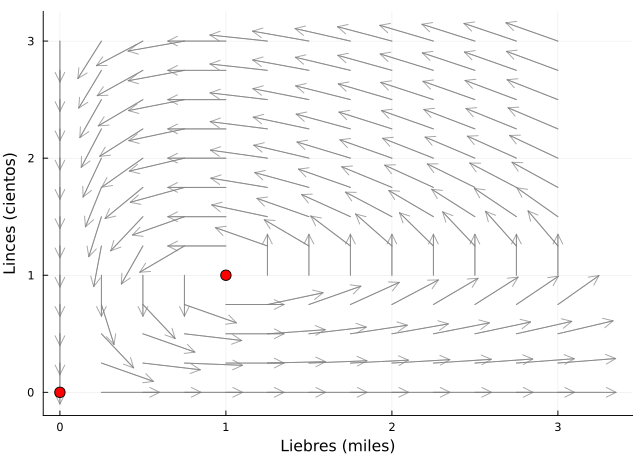

In [11]:
using Plots
f(x, y) = x * (1 - y)
g(x, y) = 0.5 * y * (x - 1)
plt = campo_vectorial(f, g, 0:0.25:3, 0:0.25:3,
    xlab = "Liebres (miles)", ylab = "Linces (cientos)", legend = false)
scatter!(plt, [0, 1], [0, 1], color = :red, ms = 6)
plt

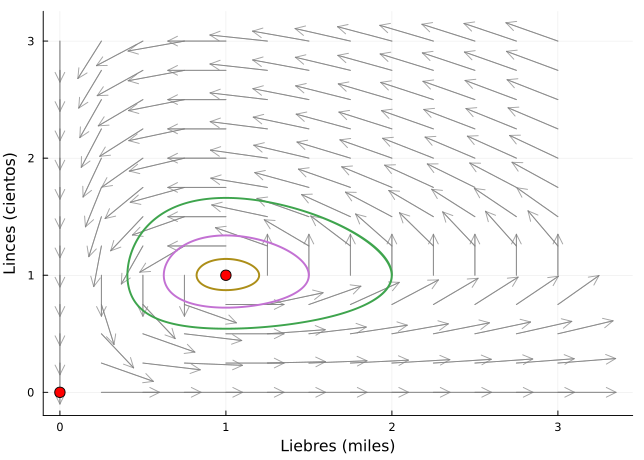

In [12]:
using DifferentialEquations
function lotka!(du, u, p, t)
    du[1] = u[1] * (1 - u[2])
    du[2] = 0.5 * u[2] * (u[1] - 1)
end
for u0 in [[2.0, 1.0], [1.5, 1.0], [1.2, 1.0]]
    sol = solve(ODEProblem(lotka!, u0, (0.0, 20.0)))
    plot!(plt, sol, idxs = (1, 2), lw = 2)
end
plt

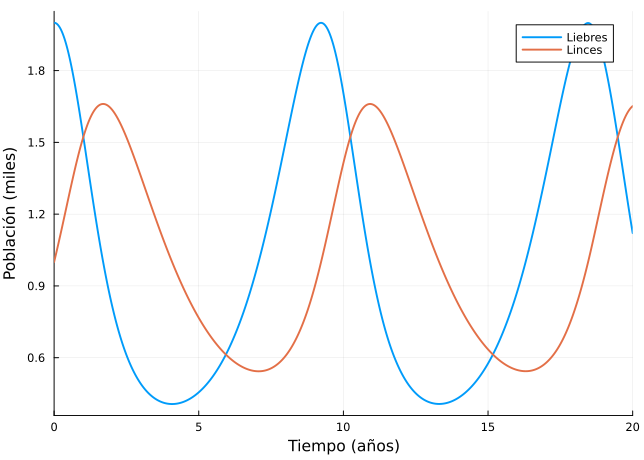

In [13]:
sol = solve(ODEProblem(lotka!, [2.0, 1.0], (0.0, 20.0)))
plot(sol, lw = 2, label = ["Liebres" "Linces"], xlab = "Tiempo (años)", ylab = "Población (miles)", legend = :topright)

In [14]:
using SymPyPythonCall
@syms θ ω
solve([ω, -sin(θ) - Sym(1)/4 * ω], [θ, ω])

2-element Vector{Tuple{Sym{PythonCall.Py}, Sym{PythonCall.Py}}}:
 (0, 0)
 (pi, 0)

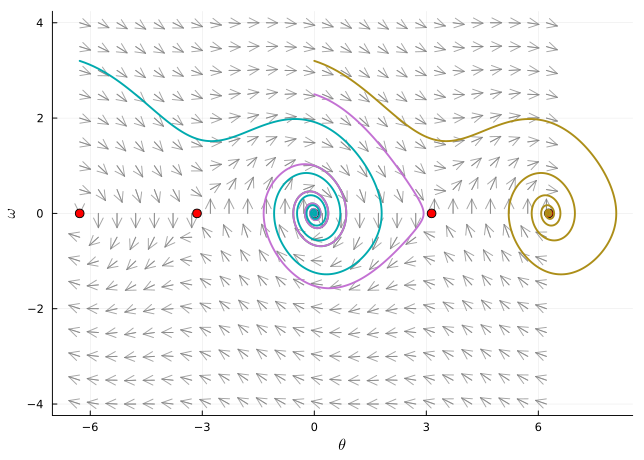

In [15]:
using Plots, DifferentialEquations, LaTeXStrings
f(θ, ω) = ω
g(θ, ω) = -sin(θ) - 0.25ω
plt = campo_vectorial(f, g, -2π:0.5:2π, -4:0.5:4, escala = 0.3,
    xlab = L"\theta", ylab = L"\omega", legend = false)
scatter!(plt, [-2π, -π, 0, π, 2π], zeros(5), color = :red, ms = 5)
function pendulo!(du, u, p, t)
    du[1] = u[2]
    du[2] = -sin(u[1]) - 0.25u[2]
end
for u0 in [[0.0, 1.0], [0.0, 2.5], [0.0, 3.2], [-2π, 3.2]]
    sol = solve(ODEProblem(pendulo!, u0, (0.0, 40.0)))
    plot!(plt, sol, idxs = (1, 2), lw = 2)
end
plt

In [16]:
using SymPyPythonCall
@syms x y
eqs = solve([x * (10 - x - 2y), y * (8 - y - Sym(3)/2 * x)], [x, y])

4-element Vector{Tuple{Sym{PythonCall.Py}, Sym{PythonCall.Py}}}:
 (0, 0)
 (0, 8)
 (3, 7/2)
 (10, 0)

In [17]:
using NLsolve
F(u) = [u[1] * (10 - u[1] - 2u[2]), u[2] * (8 - u[2] - 1.5u[1])]
nlsolve(F, [3.0, 3.0]).zero

2-element Vector{Float64}:
 3.0000000000000018
 3.4999999999999996

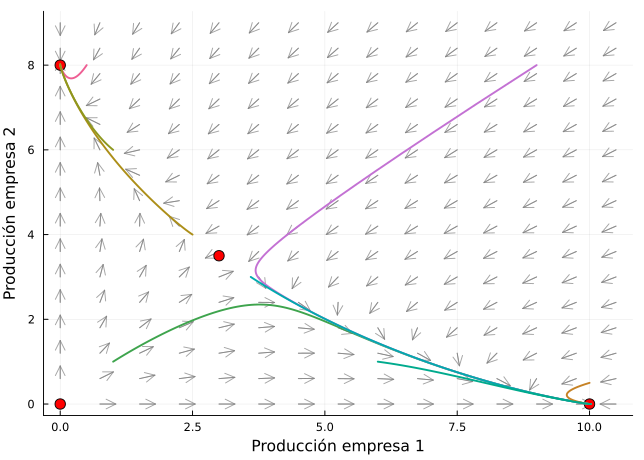

In [18]:
using Plots, DifferentialEquations
f(x, y) = x * (10 - x - 2y)
g(x, y) = y * (8 - y - 1.5x)
plt = campo_vectorial(f, g, 0:0.75:11, 0:0.6:9, escala = 0.3,
    xlab = "Producción empresa 1", ylab = "Producción empresa 2",
    legend = false)
scatter!(plt, [0, 10, 0, 3], [0, 0, 8, 3.5], color = :red, ms = 6)
function comp!(du, u, p, t)
    du[1] = u[1] * (10 - u[1] - 2u[2])
    du[2] = u[2] * (8 - u[2] - 1.5u[1])
end
for u0 in [[1,1],[9,8],[2.5,4],[3.6,3],[0.5,8],[10,0.5],[6,1],[1,6]]
    sol = solve(ODEProblem(comp!, float.(u0), (0.0, 10.0)))
    plot!(plt, sol, idxs = (1, 2), lw = 2)
end
plt

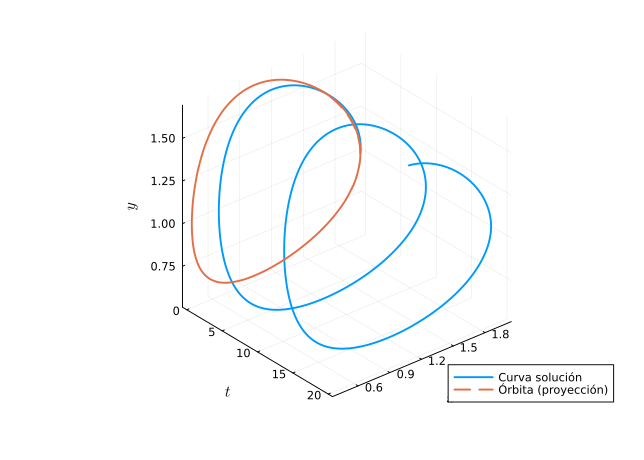

In [19]:
using Plots, DifferentialEquations, LaTeXStrings
function lotka!(du, u, p, t)
    du[1] = u[1] * (1 - u[2])
    du[2] = 0.5 * u[2] * (u[1] - 1)
end
sol = solve(ODEProblem(lotka!, [2.0, 1.0], (0.0, 20.0)), saveat = 0.05)
plot(sol.t, sol[1, :], sol[2, :], lw = 2, label = "Curva solución",
    xlab = L"t", ylab = L"x", zlab = L"y", camera = (50, 30))
plot!(fill(0, length(sol.t)), sol[1, :], sol[2, :], lw = 2, ls = :dash,
    label = "Órbita (proyección)")